In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from matplotlib.scale import scale_factory
from numpy.exceptions import ComplexWarning
from sympy.stats.sampling.sample_scipy import scipy
from scipy.optimize import differential_evolution as de
from torch.distributions.constraints import positive

from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ComplexWarning)

In [3]:
from add_roughness import *

fig = plot_density_profile(transform_array(matr,rough_res))
fig.show()

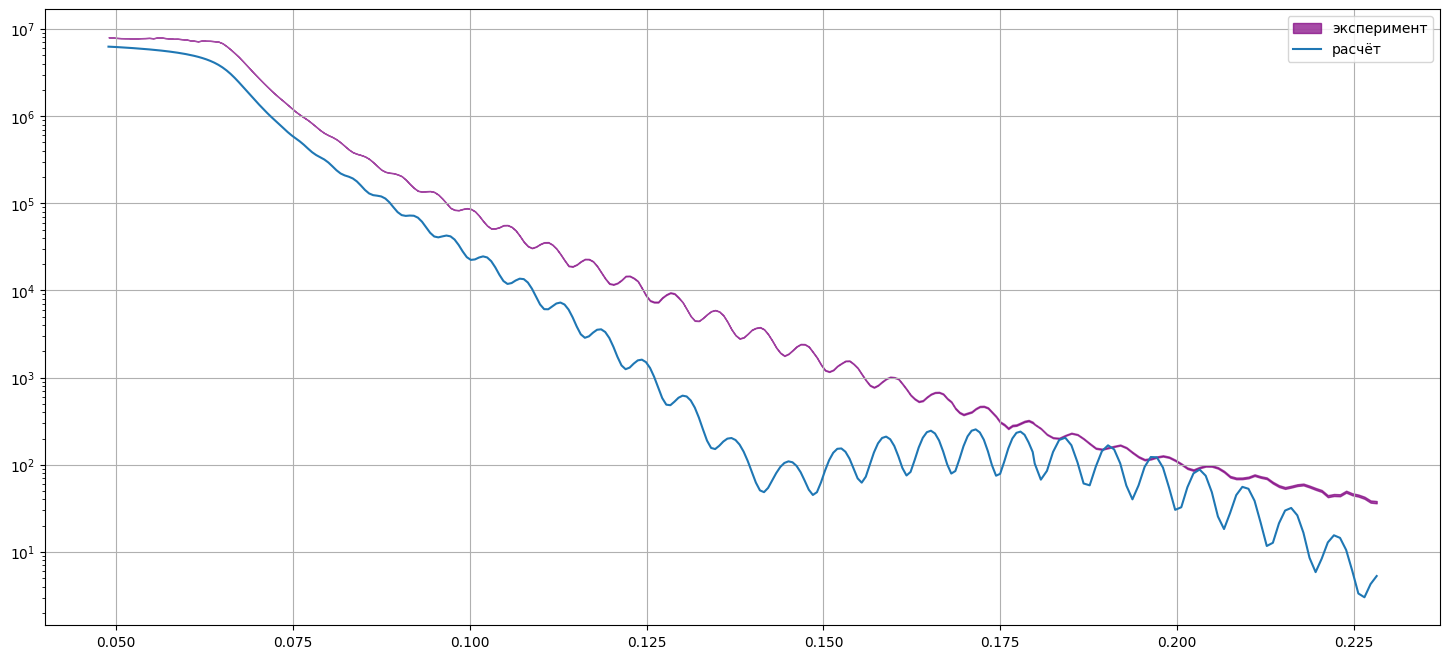

In [4]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist(), label= 'расчёт')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [5]:
from optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [6]:
from variables import *
x_d = initial_d.reshape(-1, 5)[:, 0:2].flatten()

In [7]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model')
]

learning_rates = [0.033, 0.01, 0.01, 0.01, 0.01]
iterations = [100, 200, 500, 200, 20]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses = pie_optimizer(q, r, (0.36, 0.996),    0.991,
 0.004, initial_d, initial_r_rho, initial_i_rho, I0, Ibkg,
    learning_rates,
    iterations,
    loss_classes
)

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 75.18it/s, lr=6.37e-02]


Stage 1: Learning Rate=0.033, Iterations=100, relative_loss=0.726064962743477


Optimizing: 100%|████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 80.97it/s, lr=1.84e-02]


Stage 2: Learning Rate=0.01, Iterations=200, relative_loss=0.7781031162989621


Optimizing: 100%|████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 76.90it/s, lr=1.61e-02]


Stage 3: Learning Rate=0.01, Iterations=500, relative_loss=0.7847015895617591


Optimizing: 100%|████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 69.03it/s, lr=1.84e-02]


Stage 4: Learning Rate=0.01, Iterations=200, relative_loss=0.9326447681370439


Optimizing: 100%|██████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 62.96it/s, lr=2.00e-02]


Stage 5: Learning Rate=0.01, Iterations=20, relative_loss=0.9513147549352378


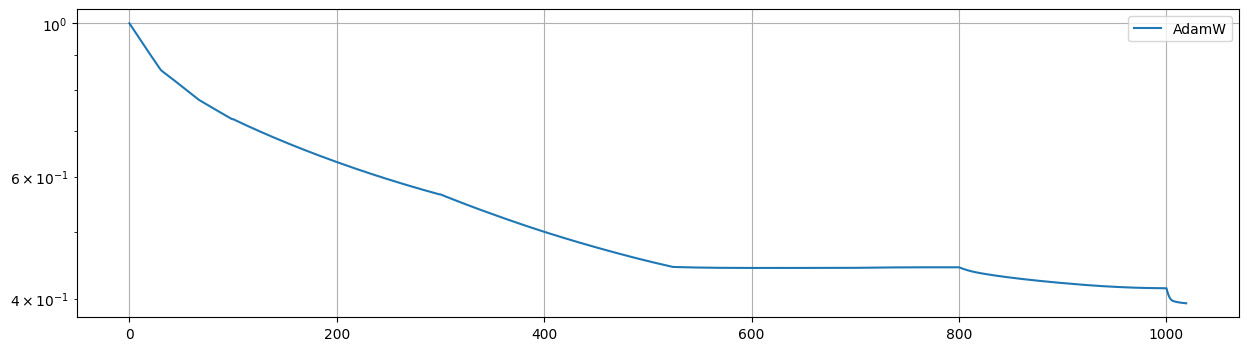

In [8]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [9]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 5, 1, 2,3,4])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), rough_res))
fig.show()

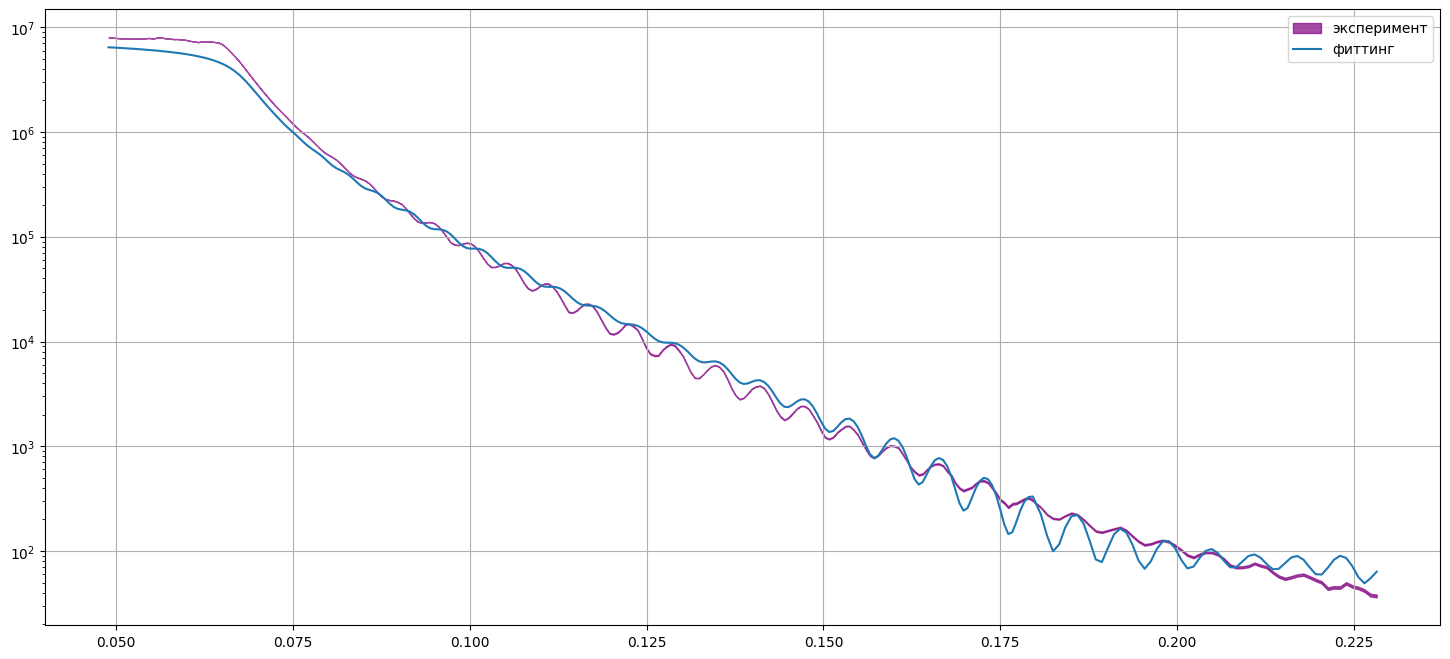

In [10]:
r_mod, r_mod_conv= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist(), label= 'фиттинг')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [11]:
def log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas=None):
    var_vector = torch.tensor(theta)
    log_f = theta[-1]
    q = q.cpu().detach().numpy()
    r_exp = r_exp.cpu().detach().numpy()

    v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    #print(v1)
    combined_x = torch.cat(
        (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
        dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
    new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)
    #print(new_matr)

    r_model, _ = reflectometry(q, new_matr, sigma1, sigma2, I0, Ibkg)
    if isinstance(r_model, torch.Tensor):
         r_model = r_model.cpu().detach().numpy()

    s2 = np.exp(2*log_f)

    r_min = np.minimum(r_exp, r_model)

    period_diff, n_diff = period_loss(q, r_model, r_exp)

    return -0.5 * np.sum(((r_exp - r_model)/r_min)**2 + 2*(period_diff+0.1)*(0.1+n_diff))


def log_prior(theta):
    summa = 0

    for o, x in enumerate(theta):
        if (np_bounds[o,0]> x or x > np_bounds[o,1]):
            summa+=1
        
    if summa>0:
        return -np.inf
    return 0



def log_probability(theta, I0, Ibkg, q, r_exp, sigmas=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas)

In [12]:
r_mod1, _ = reflectometry(q, matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

In [13]:
r_min = np.minimum(r.real.detach().numpy(), r_mod.detach().numpy())

np.sum(((r.detach().numpy() - r_mod.detach().numpy())/r_min)**2)

np.complex128(28.046495260912717+0j)

In [14]:
theta = np.array([1234.0, 44.7, 0.18, 0.8, 0.93, 73.5, 0.0, 0.48, 0.79])

var_vector = torch.tensor(theta)
log_f = theta[-1]
q = q
r_exp = r

v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    #print(v1)
combined_x = torch.cat(
    (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
    dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)

In [15]:
from calculating_dynamic_resolution import resolution_function_smooth_step
sigmas = []
for q_i in q:
    sigmas.append(resolution_function_smooth_step(q[-1], q_i, sigma1, sigma2, gap).cpu().detach().numpy())
sigmas = np.array(sigmas)

In [16]:
xt = torch.cat((ans_d[:5], ans_d[6:]), dim=0)

log_f_init = np.array([-2700])
#var_vector = np.concatenate((xt.cpu().detach().numpy(), log_f_init))
var_vector = xt.cpu().detach().numpy()

In [17]:
n_walkers = 48

sc = 0.001
sc_add = 0.0001

position = np.transpose(np.repeat(var_vector.reshape(-1, 1), n_walkers, axis = 1))

position+=position*(sc*np.random.rand(n_walkers, var_vector.shape[0])-sc/2)+(sc_add*np.random.rand(n_walkers, var_vector.shape[0])-sc_add/2)

In [18]:
for i in range(position.shape[0]):
    position[i] = np.clip(position[i], 1.0001*np_bounds[:, 0], 0.9999*np_bounds[:, 1])+(sc_add*np.random.rand(var_vector.shape[0])-sc_add/2)

In [19]:
vv = torch.tensor([[8.0730e+02, 4.4742e+01, 1.6172e-01, 7.9987e-01, 9.2319e-01],
        [3.9990e+02, 6.9824e+01, 7.4842e-02, 3.0035e-01, 9.9845e-01]])

In [20]:
combined_x = torch.cat(
        (vv, torch.complex(ans_r_rho.reshape(2, 1), ans_i_rho.reshape(2, 1))),
        dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
combined_x

tensor([[8.0730e+02+0.0000j, 9.2950e+01-8.0258j, 4.4742e+01+0.0000j,
         1.6172e-01+0.0000j, 7.9987e-01+0.0000j, 9.2319e-01+0.0000j],
        [3.9990e+02+0.0000j, 9.2000e+00+0.2855j, 6.9824e+01+0.0000j,
         7.4842e-02+0.0000j, 3.0035e-01+0.0000j, 9.9845e-01+0.0000j]])

In [21]:
log_likelihood(np.array([834.0, 44.7, 0.18, 0.8, 0.93, 73.5, 0.0, 0.48, 0.79]),  I0, Ibkg, q, r, sigmas)

np.complex128(-682.8704097082436+0j)

In [22]:
import emcee

nwalkers, ndim = position.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(I0, Ibkg, q, r, sigmas)
)
sampler.run_mcmc(position, 300, progress=True);


100%|██████████| 300/300 [01:09<00:00,  4.33it/s]


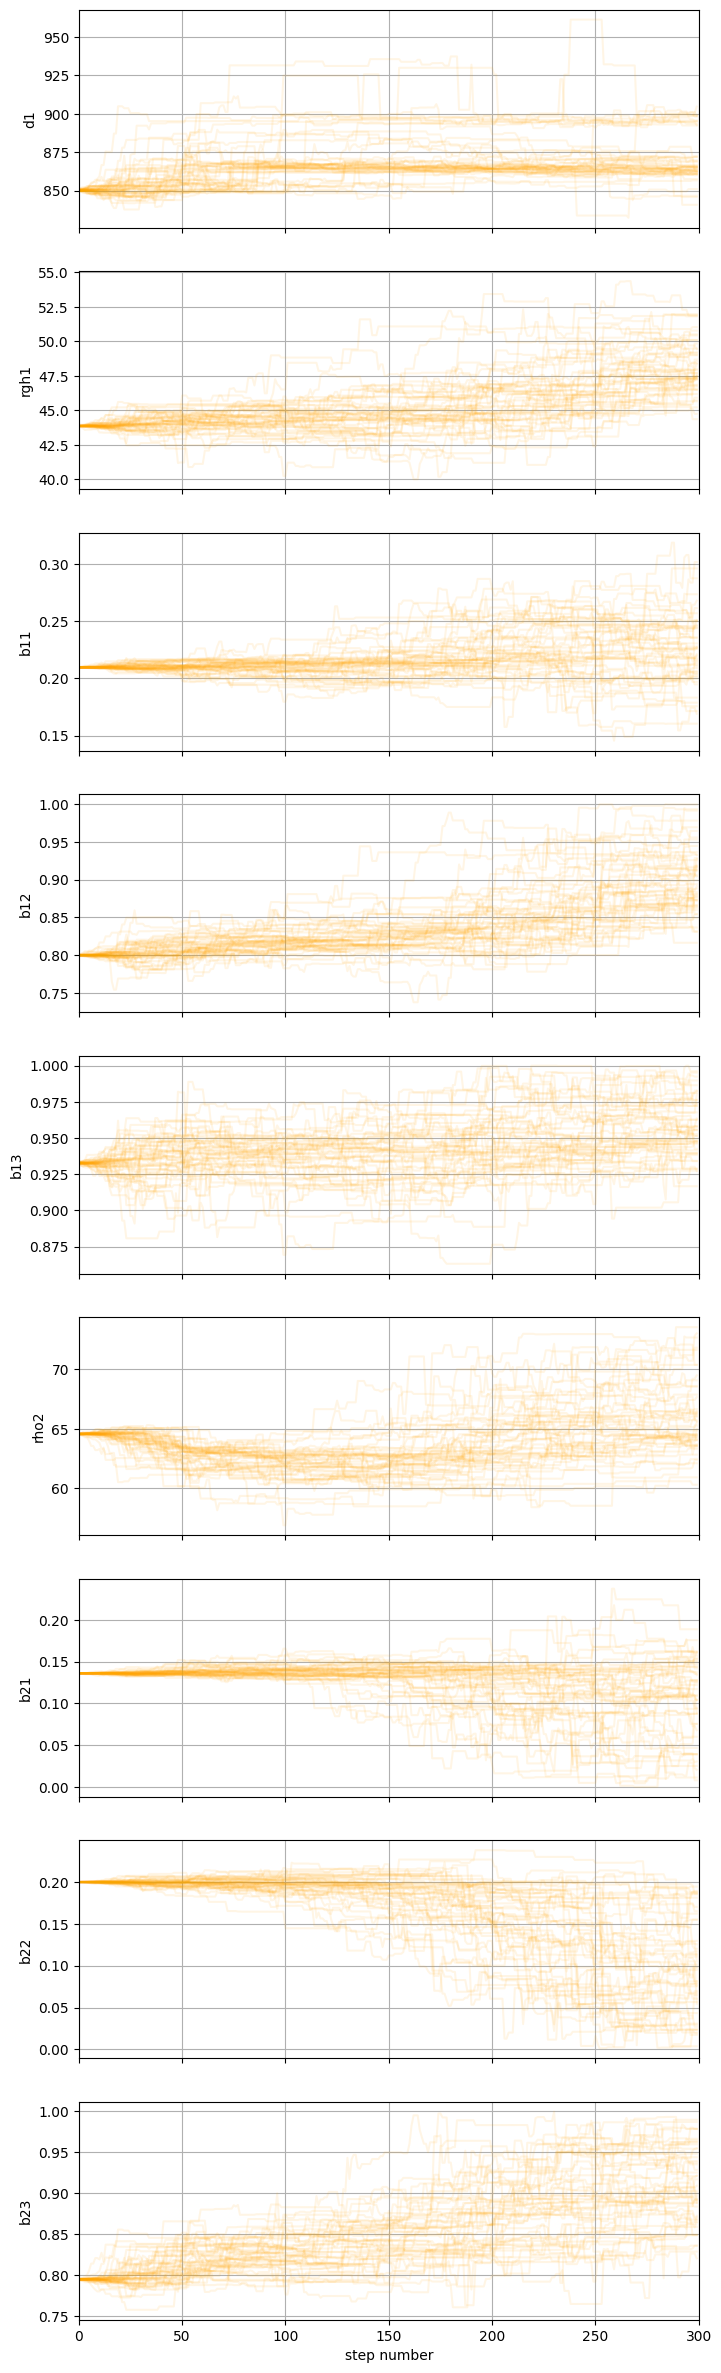

In [23]:
fig, axes = plt.subplots(9, figsize=(8, 30), sharex=True)
samples = sampler.get_chain()
labels = ["d1", "rgh1", "b11", "b12","b13", "rho2", "b21", "b22","b23"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.1, color='orange')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("step number");

In [24]:
flat_samples = sampler.get_chain(discard=200, thin=10, flat=True)

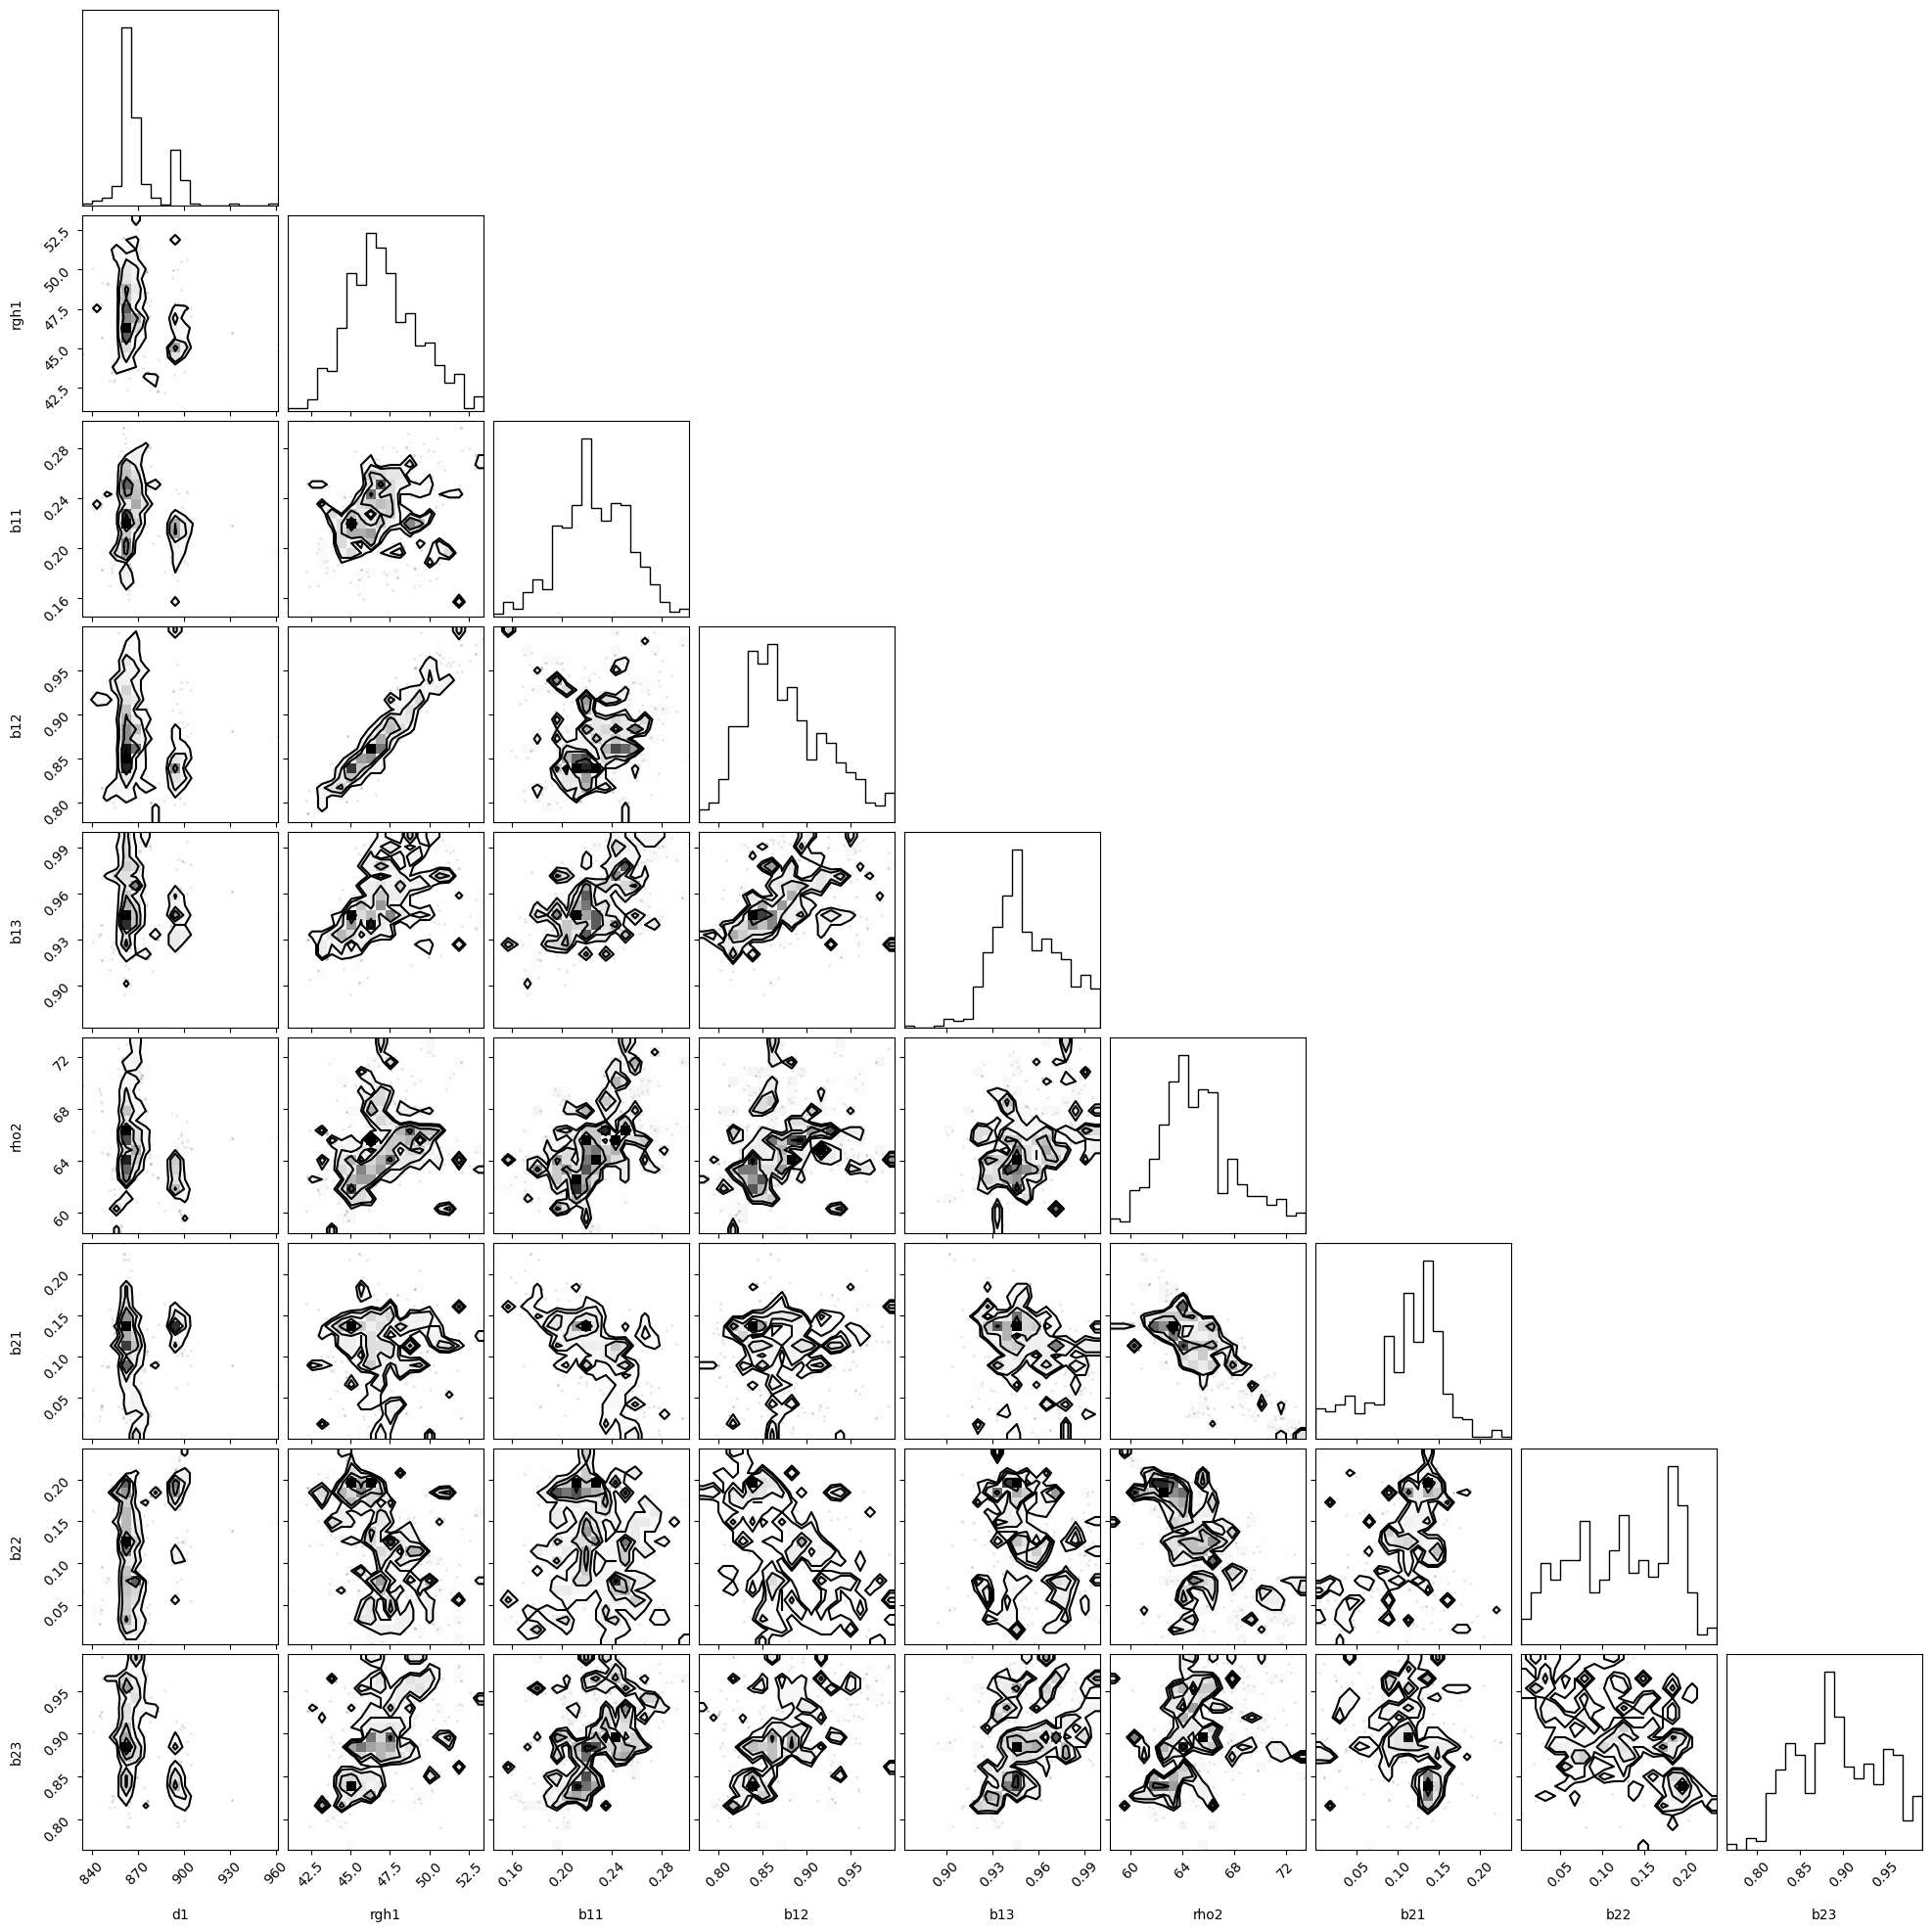

In [25]:
import corner

fig = corner.corner(
    flat_samples, labels=labels
)

In [26]:
final_samples = samples[-1, :, :]


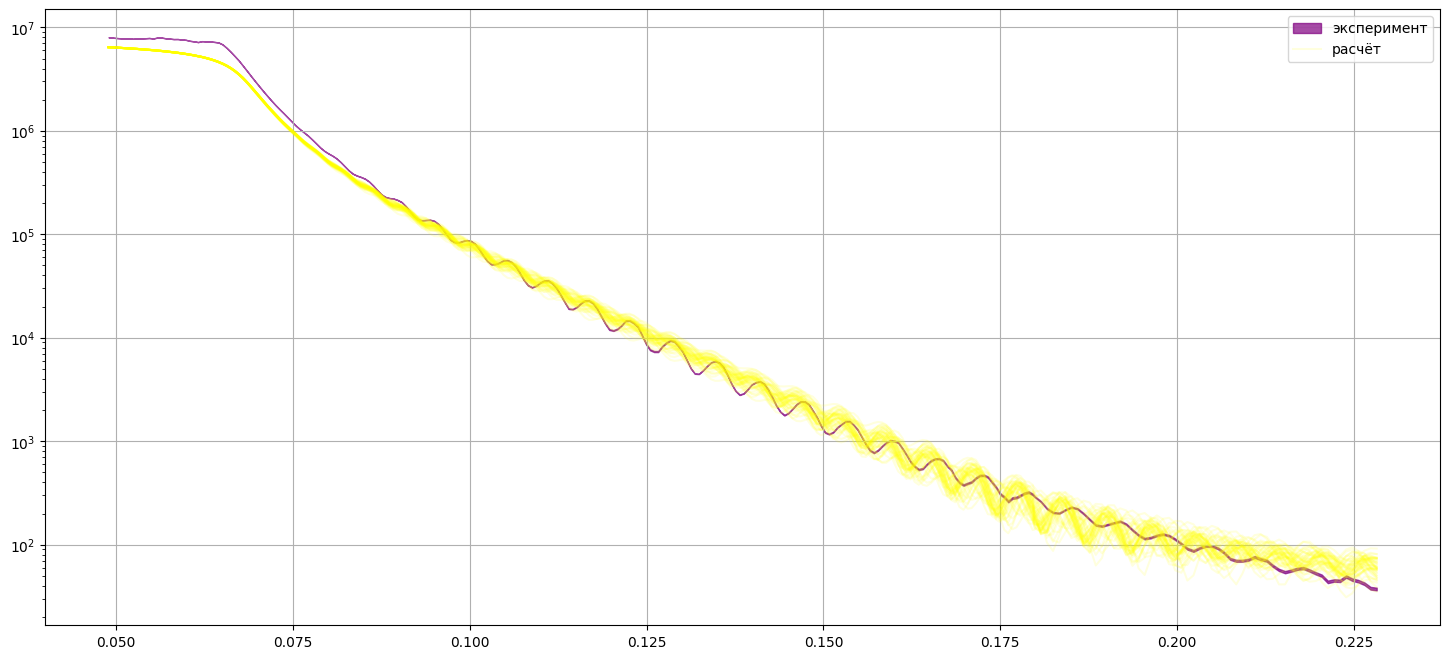

In [27]:
r_mod_list = []
matr_mod_list = []

for sample in final_samples:
    var_vector = torch.tensor(sample)

    v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    combined_x = torch.cat(
    (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
    dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
    new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)

    _, r_mod_conv2= reflectometry(q, new_matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)
    r_mod_list.append(r_mod_conv2)
    matr_mod_list.append(transform_array(new_matr, rough_res))

fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label='эксперимент')

# Отрисовка всех графиков из r_mod_list
for r_mod_conv2 in r_mod_list:
    ax.plot(q[0:len(r_mod_conv2.tolist())]*1e-10, (I0*r_mod_conv2).tolist(), color='yellow', alpha=0.13, label='расчёт' if r_mod_conv2 is r_mod_list[0] else None)

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [28]:
def plot_density_profile_variator(matr_list):
    fig = go.Figure()

    # Проходим по каждому тензору в списке
    for matr in matr_list:
        matrix = torch.tensor(matr)
        depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
        U = (1.e-0) * matrix[:, 1].real

        x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
        y_fill = torch.repeat_interleave(U, 2)

        # Добавляем график с полупрозрачностью и одинаковым цветом
        fig.add_trace(go.Scatter(
            x=x_fill.detach().cpu().numpy(),
            y=y_fill.detach().cpu().numpy(),
            mode="lines",
            line=dict(color="darkgreen"),
            opacity=0.8,  # Полупрозрачность
            showlegend=(matr is matr_list[0])  # Показываем легенду только для первого графика
        ))

    # Настройки осей и макета
    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

fig = plot_density_profile_variator(matr_mod_list)
fig.show()

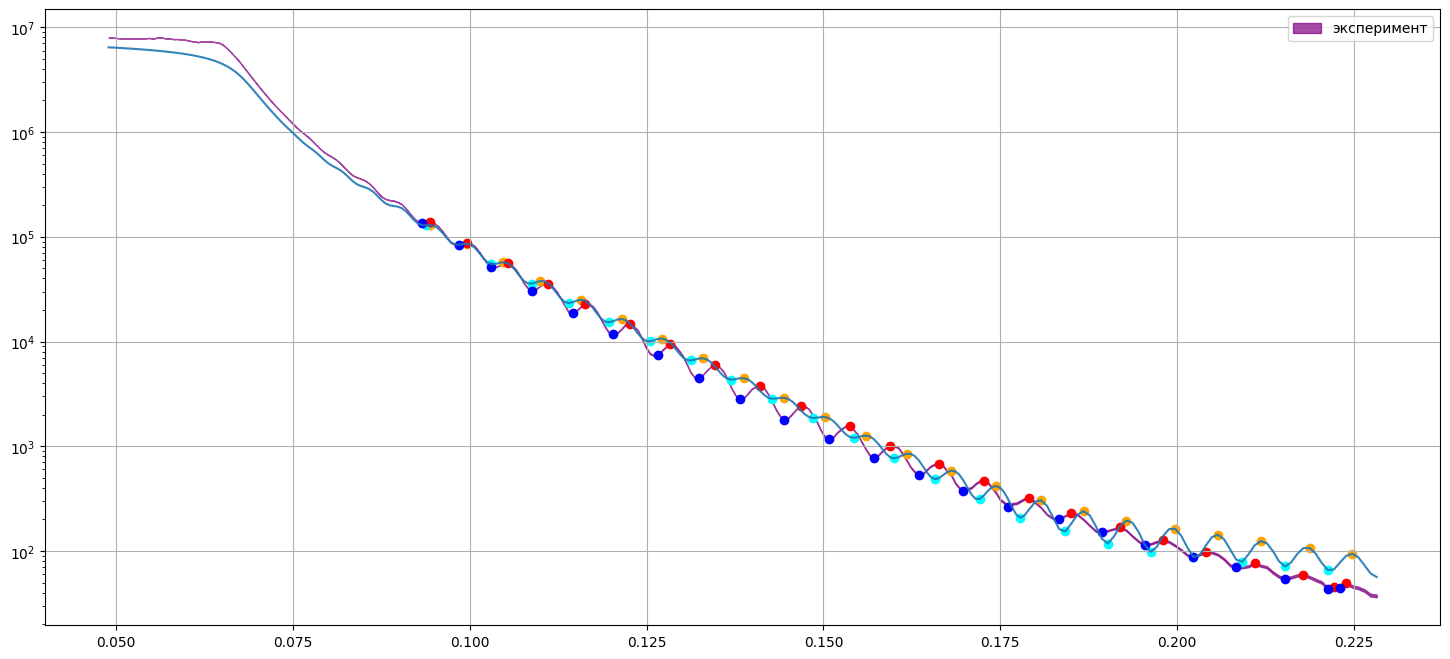

In [29]:
fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label='эксперимент')

for i, y in enumerate(r_mod_list[15:16]):
    y = y.real
    rx = torch.tensor(r0)

    below_threshold = torch.where(rx < 0.5)[0]
    below_threshold1 = torch.where(y < 0.5)[0]
    if len(below_threshold) == 0:
        crit_dot = 0
    else:
        crit_dot = below_threshold[0]

    if len(below_threshold1) == 0:
        crit_dot1 = 0
    else:
        crit_dot1 = below_threshold1[0]

    left = y[:-2]
    center = y[1:-1]
    right = y[2:]

    left1 = rx[:-2]
    center1 = rx[1:-1]
    right1 = rx[2:]


    max_mask = (center > left) & (center > right)
    min_mask = (center < left) & (center < right)

    max_mask1 = (center1 > left1) & (center1 > right1)
    min_mask1 = (center1 < left1) & (center1 < right1)

    # Фильтрация индексов
    raw_max_indices = torch.where(max_mask)[0] + 1
    raw_min_indices = torch.where(min_mask)[0] + 1

    raw_max_indices1 = torch.where(max_mask1)[0] + 1
    raw_min_indices1 = torch.where(min_mask1)[0] + 1

    max_indices = raw_max_indices[raw_max_indices > crit_dot]
    min_indices = raw_min_indices[raw_min_indices > crit_dot]

    #print(raw_max_indices, '\n', raw_max_indices1 > crit_dot1)
    max_indices1 = raw_max_indices1[raw_max_indices1 > crit_dot1]
    min_indices1 = raw_min_indices1[raw_min_indices1 > crit_dot1]

    # Получение координат и их
    x_max = (q[max_indices])
    y_max = (y[max_indices])
    x_min = (q[min_indices])
    y_min = (y[min_indices])

    x_max1 = (q[max_indices1])
    y_max1 = (r0[max_indices1])
    x_min1 = (q[min_indices1])
    y_min1 = (r0[min_indices1])

    x_crit =q[crit_dot]

    avg_period_mod = torch.mean(x_max[1:-1]- x_max[0:-2])*0.5e-10+torch.mean(x_min[1:-1]- x_min[0:-2])*0.5e-10
    avg_period_exp = torch.mean(x_max1[1:-1]- x_max1[0:-2])*0.5e-10+torch.mean(x_min1[1:-1]- x_min1[0:-2])*0.5e-10

    ax.plot(q[0:len(y.tolist())]*1e-10, (I0*y).tolist(), alpha=0.9, label='расчёт '+str(i) if y is r_mod_list[0] else None)
    #ax.scatter(x_crit*1e-10, 0.5*I0.cpu().detach().numpy(), color='red')
    ax.scatter(x_max.detach().numpy()*1e-10, I0.cpu().detach().numpy()*y_max.detach().numpy(), color='orange')
    ax.scatter(x_min.detach().numpy()*1e-10, I0.cpu().detach().numpy()*y_min.detach().numpy(), color='cyan')

    ax.scatter(x_max1*1e-10, y_max1, color='red')
    ax.scatter(x_min1*1e-10, y_min1, color='blue')

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [30]:
avg_period = torch.mean(x_max[1:-1]- x_max[0:-2])*0.5e-10+torch.mean(x_min[1:-1]- x_min[0:-2])*0.5e-10
avg_period1 = torch.mean(x_max1[1:-1]- x_max1[0:-2])*0.5e-10+torch.mean(x_min1[1:-1]- x_min1[0:-2])*0.5e-10

In [31]:
r_mod_x = r_mod_list[15]
rel_period, n_diff = period_loss(q, r_mod_x.real, r0)